# Load a wav file

In [4]:
#imports 
import torch 
import torchaudio
import matplotlib.pyplot as plt 

In [11]:
#data sample 
data_sample = "../data/unique_sample/Phantom_in_the_Maze.mp3"
waveform, sample_rate = torchaudio.load(data_sample)
print(waveform.shape)
print(sample_rate)

torch.Size([2, 1357056])
44100


In [6]:
#Reducing data sample size by two 
if waveform.shape[0] > 1: 
    waveform = torch.mean(waveform,dim=0,keepdim=True)

In [12]:
#stft parameters
# n_fft : La "résolution" des fréquences (2048 est le standard en musique)
# hop_length : Le nombre d'échantillons entre chaque "colonne" de pixels (le temps)
n_fft = 2048
hop_length = 512

In [13]:
# creating the stft image 
# return_complex=True est la norme sur les versions récentes de PyTorch
stft_result = torch.stft(
    waveform,
    n_fft=n_fft,
    hop_length=hop_length,
    return_complex=True
)

c:\Users\ggyor\miniconda3\envs\hf-audio-stem\lib\site-packages\torch\functional.py:704: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


In [18]:
#Récupération de la magnitude et de la phase 
magnitude = torch.abs(stft_result)  # L'intensité (notre future "image")
phase = torch.angle(stft_result)    # Le timing (à garder de côté pour la fin)
magnitude_db = 20 * torch.log10(magnitude + 1e-5)
print(magnitude.shape)
print(phase.shape)
print(magnitude_db.shape)

torch.Size([2, 1025, 2651])
torch.Size([2, 1025, 2651])
torch.Size([2, 1025, 2651])


# Creation of the image

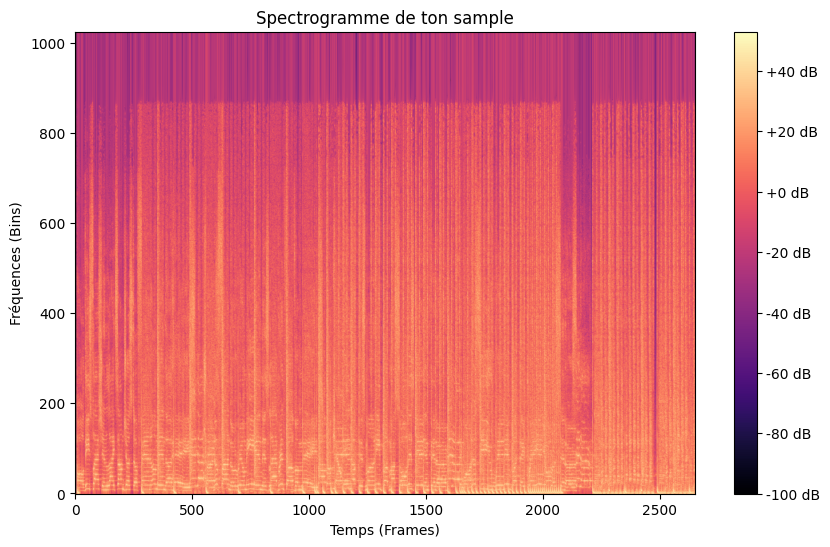

Dimension de l'image (Tenseur) : torch.Size([2, 1025, 2651])


In [16]:
plt.figure(figsize=(10, 6))
plt.imshow(magnitude_db[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title("Spectrogramme de ton sample")
plt.xlabel("Temps (Frames)")
plt.ylabel("Fréquences (Bins)")
plt.colorbar(format="%+2.0f dB")
plt.show()
print(f"Dimension de l'image (Tenseur) : {magnitude_db.shape}")